In [4]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# load Data
df = pd.read_csv("credit_risk_dataset.csv")

In [6]:
df.shape

(32581, 12)

In [7]:
# info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [8]:
# Missing Values
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [9]:
# Target Balance

df['loan_status'].value_counts()
# Here data is imbalance 

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

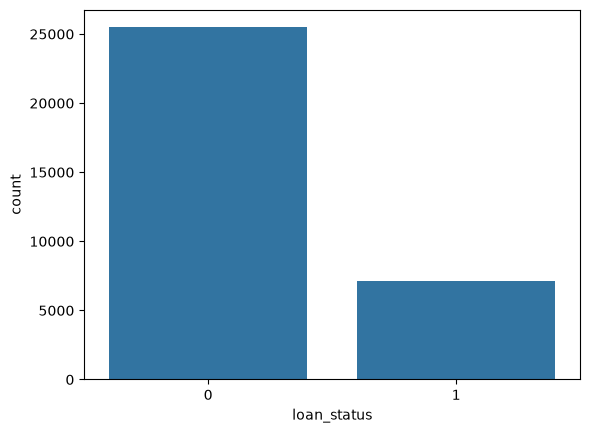

In [10]:
sns.countplot(x='loan_status', data=df)

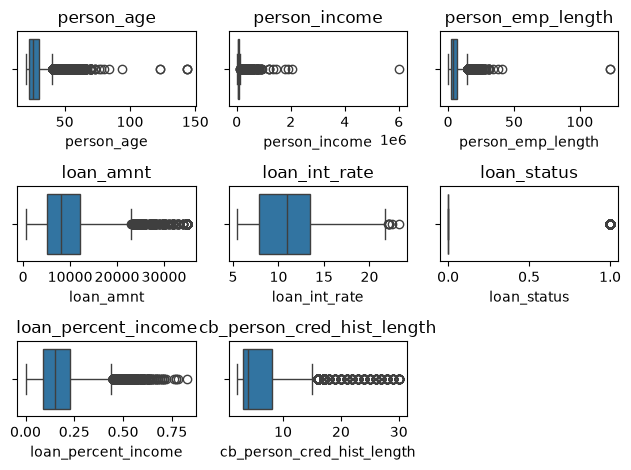

In [11]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.subplot(3, 3, list(numerical_cols).index(col) + 1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [12]:
(df['person_age'] > 100).sum()

np.int64(5)

In [13]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

In [14]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


<Axes: >

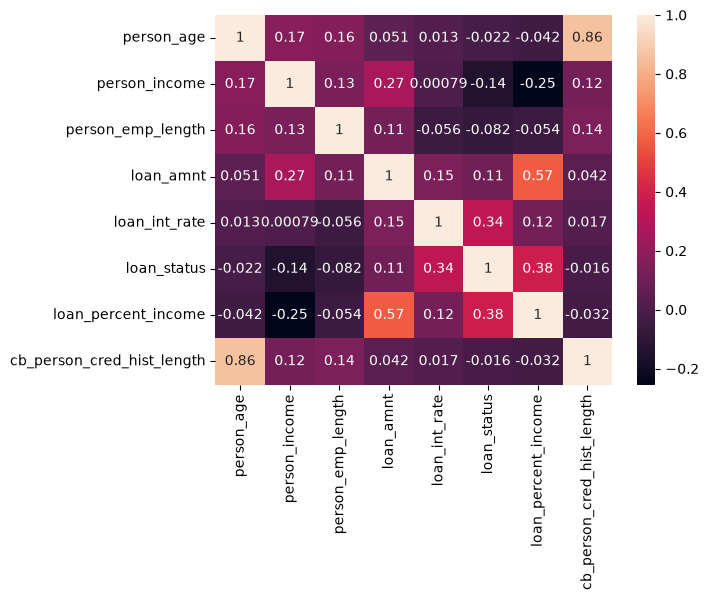

In [15]:
# correlation check

sns.heatmap(df.corr(numeric_only=True), annot=True)

In [16]:
# Outlier Handling

df_copy = df.copy()
print(f"Original Rows: {df_copy.shape[0]}")

#Remove Duplicate rows
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates : {df_copy.shape[0]}")

#Remove ages below 18 or below 100
df_copy = df_copy[df_copy['person_age'] >=18]
df_copy = df_copy[df_copy['person_age'] <=100]

#Remove employment length greater than age or extreme outliers (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

#Remove the rows with zero or negative income and loan amount.
df_copy = df_copy[df_copy['loan_amnt'] > 0]

#check if the interest rate looks realistic.
print("Loan intreset rate range from (min: 5.42 and max: 23.22)")

Original Rows: 32581
Rows after removing duplicates : 32416
Loan intreset rate range from (min: 5.42 and max: 23.22)
